# Reading a DESI acquisition with `wraw`

This notebook opens a private Waters RAW directory, inspects its run and function metadata, plots a representative mass spectrum, and visualizes its spatial total ion current. The data itself is not distributed with the repository.

> **Dataset citation:** _Gabriel, A.; Jamzad, A.; Farahmand, M.; Kaufmann, M.; Iaboni, N.; Hurlbut, D.; Ren, K.Y.M.; Nicol, C.J.B.; Rudan, J.F.; Varma, S.; et al. Application of Foundation Models for Colorectal Cancer Tissue Classification in Mass Spectrometry Imaging. Technologies 2025, 13, 434. https://doi.org/10.3390/technologies13100434_

## Point the notebook at the private data

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import wraw

sns.set_theme(style="ticks", context="notebook")

raw_path = Path(r'D:\Datasets\Proprietory\DESI\Colon\example.raw')
raw = wraw.read(raw_path)
function = raw.function(1)
raw.path.name

'example.raw'

## Run and function metadata

In [2]:
run_fields = {
    "File": raw.path.name,
    "Acquired name": raw.metadata.get("Acquired Name"),
    "Acquired date": raw.metadata.get("Acquired Date"),
    "Acquired time": raw.metadata.get("Acquired Time"),
    "Instrument": raw.metadata.get("Instrument"),
    "Polarity": raw.polarity,
    "Functions": len(raw.functions),
}
run_fields

{'File': 'example.raw',
 'Acquired name': '2021 03 31 colon 1258561-2 Analyte 7',
 'Acquired date': '27-Jan-2010',
 'Acquired time': '03:32:15',
 'Instrument': 'XEVO-G2XSQTOF#NotSet',
 'Polarity': 'ES-',
 'Functions': 1}

In [3]:
function_fields = {
    "Number": function.number,
    "Description": function.description,
    "Data format": function.data_format,
    "Scans": function.scan_count,
    "Mass range": f"{function.mass_range[0]:g}–{function.mass_range[1]:g} m/z",
    "Scan time": f"{function.scan_time_s:g} s",
    "Interscan time": f"{function.interscan_time_s:g} s",
    "Record encoding": function.encoding,
}
function_fields

{'Number': 1,
 'Description': 'TOF MS FUNCTION',
 'Data format': 'Continuum',
 'Scans': 45013,
 'Mass range': '50–1500 m/z',
 'Scan time': '0.557 s',
 'Interscan time': '0.014 s',
 'Record encoding': 'bitpacked8'}

## A representative spectrum

Only the selected scan is read and decoded. Seaborn plots the arrays returned by `wraw` directly.

{'scan_index': 22222,
 'retention_time_min': 228.13912963867188,
 'points': 45664,
 'tic': 771426.0,
 'base_peak_mz': 281.2738952636719,
 'base_peak_intensity': 6513.0}

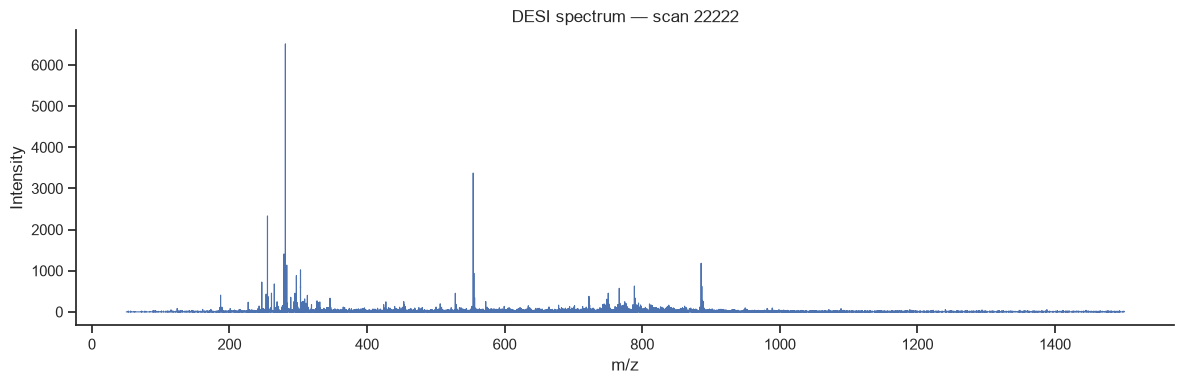

In [4]:
scan_index = 22222  # Just an example
spectrum = function.read_spectrum(scan_index)

spectrum_fields = {
    "scan_index": spectrum.scan_index,
    "retention_time_min": spectrum.retention_time_min,
    "points": spectrum.mz.size,
    "tic": spectrum.tic,
    "base_peak_mz": float(spectrum.mz[spectrum.base_peak_index]),
    "base_peak_intensity": float(spectrum.intensity[spectrum.base_peak_index]),
}
display(spectrum_fields)

figure, axis = plt.subplots(figsize=(12, 4))
sns.lineplot(x=spectrum.mz, y=spectrum.intensity, estimator=None, sort=False, linewidth=0.8, ax=axis)
axis.set(title=f"DESI spectrum — scan {scan_index}", xlabel="m/z", ylabel="Intensity")
sns.despine()
figure.tight_layout()

## Spatial total ion current

The raster dimensions come from the native DESI length and step metadata. The RAW scan index stores each scan's TIC, so constructing the image does not require decoding every spectrum. `log1p` compresses the intensity range while preserving zero-valued pixels. This acquisition contains 45,013 indexed scans for 45,012 raster positions; without a native coordinate table, the image uses the first raster-sized block of scans.

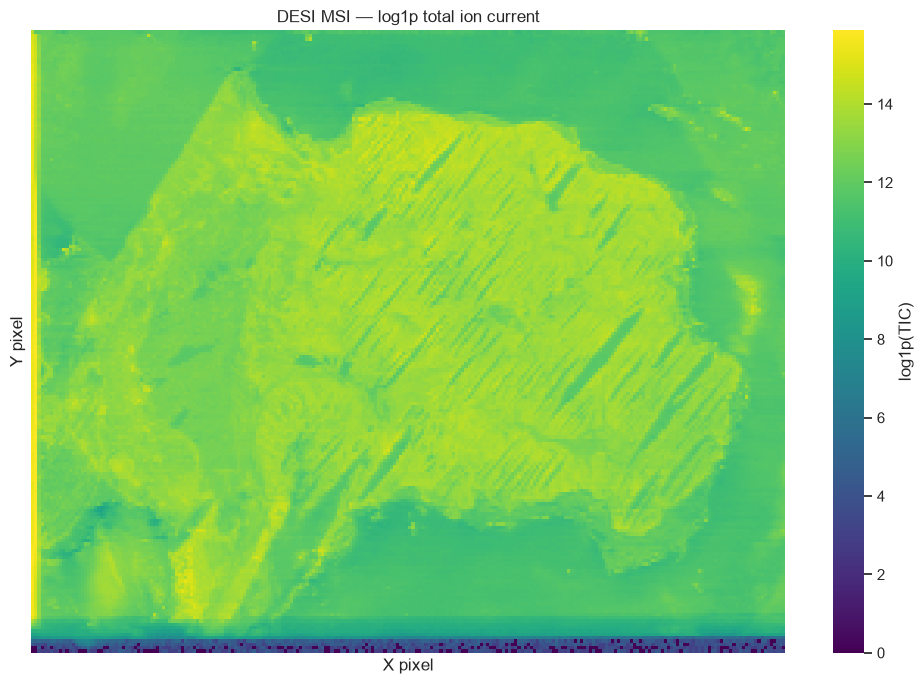

In [5]:
x_pixels = round(float(raw.metadata["DesiXLength"]) / float(raw.metadata["DesiXStep"]))
y_pixels = round(float(raw.metadata["DesiYLength"]) / float(raw.metadata["DesiYStep"]))
pixel_count = x_pixels * y_pixels
if function.scan_count < pixel_count:
    raise ValueError(f"Expected {pixel_count} pixel scans, found {function.scan_count}")

tic_image = function.tic[:pixel_count].reshape(y_pixels, x_pixels)

figure, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(np.log1p(tic_image), cmap="viridis", xticklabels=False, yticklabels=False, cbar_kws={"label": "log1p(TIC)"}, ax=axis)
axis.set(title="DESI MSI — log1p total ion current", xlabel="X pixel", ylabel="Y pixel")
figure.tight_layout()